# BFS

## 二维网格

<span id='P.130'></span>
### [130. 被围绕的区域](https://leetcode.cn/problems/surrounded-regions/)
给你一个`m x n`的矩阵`board`，由若干字符`'X'`和`'O'`组成，**捕获**所有**被围绕的区域**：

- 连接：一个单元格与水平或垂直方向上相邻的单元格连接。
- 区域：**连接所有**`'O'`的单元格来形成一个区域。
- 围绕：如果您可以用`'X'`单元格**连接这个区域**，并且区域中没有任何单元格位于`board`边缘，则该区域被`'X'`单元格围绕。

通过**原地**将输入矩阵中的所有`'O'`替换为`'X'`来**捕获被围绕的区域**。你不需要返回任何值。

In [17]:
board = [["X","O","O","X","X","X","O","X","O","O"],
         ["X","O","X","X","X","X","X","X","X","X"],
         ["X","X","X","X","O","X","X","X","X","X"],
         ["X","O","X","X","X","O","X","X","X","O"],
         ["O","X","X","X","O","X","O","X","O","X"],
         ["X","X","O","X","X","O","O","X","X","X"],
         ["O","X","X","O","O","X","O","X","X","O"],
         ["O","X","X","X","X","X","O","X","X","X"],
         ["X","O","O","X","X","O","X","X","O","O"],
         ["X","X","X","O","O","X","O","X","X","O"]]

global_visited = [[board[ii][jj] for jj in range(len(board[0]))] for ii in range(len(board))]
for mm in range(1, len(board) - 1):
    for nn in range(1, len(board[0]) - 1):
        if global_visited[mm][nn] == 'O':
            record = [(mm, nn)]
            global_visited[mm][nn] = 'X'
            bfs_visited = set([(mm, nn)])
            label = True
            while record:
                record_new = []
                for ii, jj in record:
                    if 0 <= ii - 1 and global_visited[ii - 1][jj] ==  'O':
                        record_new.append((ii - 1, jj))
                        bfs_visited.add((ii - 1, jj))
                        global_visited[ii - 1][jj] = 'X'
                        if ii - 1 == 0:
                            label = False
                    if ii + 1 < len(board) and global_visited[ii + 1][jj] ==  'O':
                        record_new.append((ii + 1, jj))
                        bfs_visited.add((ii + 1, jj))
                        global_visited[ii + 1][jj] = 'X'
                        if ii + 1 == len(board) - 1:
                            label = False
                    if 0 <= jj - 1 and global_visited[ii][jj - 1] ==  'O':
                        record_new.append((ii, jj - 1))
                        bfs_visited.add((ii, jj - 1))
                        global_visited[ii][jj - 1] = 'X'
                        if jj - 1 == 0:
                            label = False
                    if jj + 1 < len(board[0]) and global_visited[ii][jj + 1] ==  'O':
                        record_new.append((ii, jj + 1))
                        bfs_visited.add((ii, jj + 1))
                        global_visited[ii][jj + 1] = 'X'
                        if jj + 1 == len(board[0]) - 1:
                            label = False
                record = record_new
            if label:
                for ii, jj in bfs_visited:
                    board[ii][jj] = "X"

for row in board:
    print(row)

['X', 'O', 'O', 'X', 'X', 'X', 'O', 'X', 'O', 'O']
['X', 'O', 'X', 'X', 'X', 'X', 'X', 'X', 'X', 'X']
['X', 'X', 'X', 'X', 'X', 'X', 'X', 'X', 'X', 'X']
['X', 'X', 'X', 'X', 'X', 'X', 'X', 'X', 'X', 'O']
['O', 'X', 'X', 'X', 'X', 'X', 'X', 'X', 'X', 'X']
['X', 'X', 'X', 'X', 'X', 'X', 'X', 'X', 'X', 'X']
['O', 'X', 'X', 'X', 'X', 'X', 'X', 'X', 'X', 'O']
['O', 'X', 'X', 'X', 'X', 'X', 'X', 'X', 'X', 'X']
['X', 'X', 'X', 'X', 'X', 'X', 'X', 'X', 'O', 'O']
['X', 'X', 'X', 'O', 'O', 'X', 'O', 'X', 'X', 'O']


<span id='P.200'></span> 
#### [200. 岛屿数量](https://leetcode.cn/problems/number-of-islands/)
给你一个由`'1'`（陆地）和`'0'`（水）组成的的二维网格，请你计算网格中岛屿的数量。<br>
岛屿总是被水包围，并且每座岛屿只能由水平方向和/或竖直方向上相邻的陆地连接形成。<br>
此外，你可以假设该网格的四条边均被水包围。

In [18]:
grid = [
  ["1","1","0","0","0"],
  ["1","1","0","0","0"],
  ["0","0","1","0","0"],
  ["0","0","0","1","1"]]

global_visited = [[grid[ii][jj] for jj in range(len(grid[0]))] for ii in range(len(grid))]
count = 0
for mm in range(len(grid)):
    for nn in range(len(grid[0])):
        if global_visited[mm][nn] == '1':
            # print("------ mm =", mm, ", nn =", nn)
            record = set([(mm, nn)])
            global_visited[mm][nn] = '0'
            while record:
                record_new = set()
                for ii, jj in record:
                    if 0 <= ii - 1 and global_visited[ii - 1][jj] == '1':
                        record_new.add((ii - 1, jj))
                        global_visited[ii - 1][jj] = '0'
                    if ii + 1 < len(grid) and global_visited[ii + 1][jj] == '1':
                        record_new.add((ii + 1, jj))
                        global_visited[ii + 1][jj] = '0'
                    if 0 <= jj - 1 and global_visited[ii][jj - 1] == '1':
                        record_new.add((ii, jj - 1))
                        global_visited[ii][jj - 1] = '0'
                    if jj + 1 < len(grid[0]) and global_visited[ii][jj + 1] == '1':
                        record_new.add((ii, jj + 1))
                        global_visited[ii][jj + 1] = '0'
                record = record_new
                # print(record_new)
            count += 1
print( count )

3


<span id='P.695'></span>
#### [695. 岛屿的最大面积](https://leetcode.cn/problems/max-area-of-island/)
给你一个大小为`m x n`的二进制矩阵`grid`。

岛屿 是由一些相邻的`1`(代表土地) 构成的组合，这里的「相邻」要求两个`1`必须在**水平或者竖直的四个方向上**相邻。你可以假设`grid`的四个边缘都被`0`(代表水)包围着。

岛屿的面积是岛上值为`1`的单元格的数目。

计算并返回`grid`中最大的岛屿面积。如果没有岛屿，则返回面积为`0`。

**示例 1**:
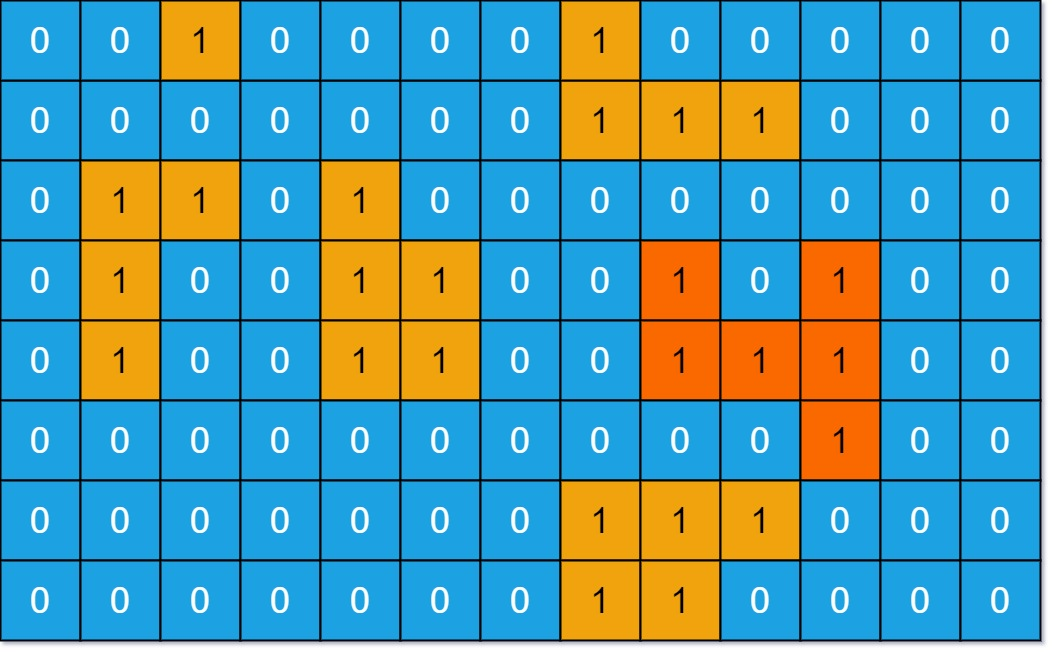

In [19]:
grid = [
    [0,0,1,0,0,0,0,1,0,0,0,0,0],
    [0,0,0,0,0,0,0,1,1,1,0,0,0],
    [0,1,1,0,1,0,0,0,0,0,0,0,0],
    [0,1,0,0,1,1,0,0,1,0,1,0,0],
    [0,1,0,0,1,1,0,0,1,1,1,0,0],
    [0,0,0,0,0,0,0,0,0,0,1,0,0],
    [0,0,0,0,0,0,0,1,1,1,0,0,0],
    [0,0,0,0,0,0,0,1,1,0,0,0,0]]

global_visited = [[grid[ii][jj] for jj in range(len(grid[0]))] for ii in range(len(grid))]
area_max = 0
for mm in range(len(grid)):
    for nn in range(len(grid[0])):
        if global_visited[mm][nn] == 1:
            # print("------ mm =", mm, ", nn =", nn)
            area = 1
            record = set([(mm, nn)])
            global_visited[mm][nn] = 0
            while record:
                record_new = set()
                for ii, jj in record:
                    if 0 <= ii - 1 and global_visited[ii - 1][jj] == 1:
                        area += 1
                        record_new.add((ii - 1, jj))
                        global_visited[ii - 1][jj] = 0
                    if ii + 1 < len(grid) and global_visited[ii + 1][jj] == 1:
                        area += 1
                        record_new.add((ii + 1, jj))
                        global_visited[ii + 1][jj] = 0
                    if 0 <= jj - 1 and global_visited[ii][jj - 1] == 1:
                        area += 1
                        record_new.add((ii, jj - 1))
                        global_visited[ii][jj - 1] = 0
                    if jj + 1 < len(grid[0]) and global_visited[ii][jj + 1] == 1:
                        area += 1
                        record_new.add((ii, jj + 1))
                        global_visited[ii][jj + 1] = 0
                record = record_new
            # print("area =", area)
            area_max = max(area_max, area)
print( area_max )

6


<span id='P.463'></span> 
### [463. 岛屿的周长](https://leetcode.cn/problems/island-perimeter/)
给定一个`row x col`的二维网格地图`grid`，其中：`grid[i][j] = 1`表示陆地，`grid[i][j] = 0`表示水域。<br>
网格中的格子**水平和垂直**方向相连（对角线方向不相连）。整个网格被水完全包围，但其中恰好有一个岛屿（或者说，一个或多个表示陆地的格子相连组成的岛屿）。<br>
岛屿中没有“湖”（“湖” 指水域在岛屿内部且不和岛屿周围的水相连）。格子是边长为 1 的正方形。网格为长方形，且宽度和高度均不超过 100 。计算这个岛屿的周长。

**示例 1**：
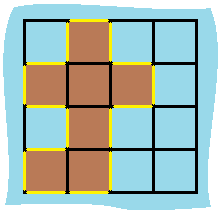
> 输入：grid = [[0,1,0,0],[1,1,1,0],[0,1,0,0],[1,1,0,0]]<br>
输出：16<br>
解释：它的周长是上面图片中的 16 个黄色的边

> 题解:
**岛屿的周长就是岛屿方格和非岛屿方格相邻的边的数量**。注意，这里的非岛屿方格，既包括**水域方格**，也包括**网格边界**，如下图所示：
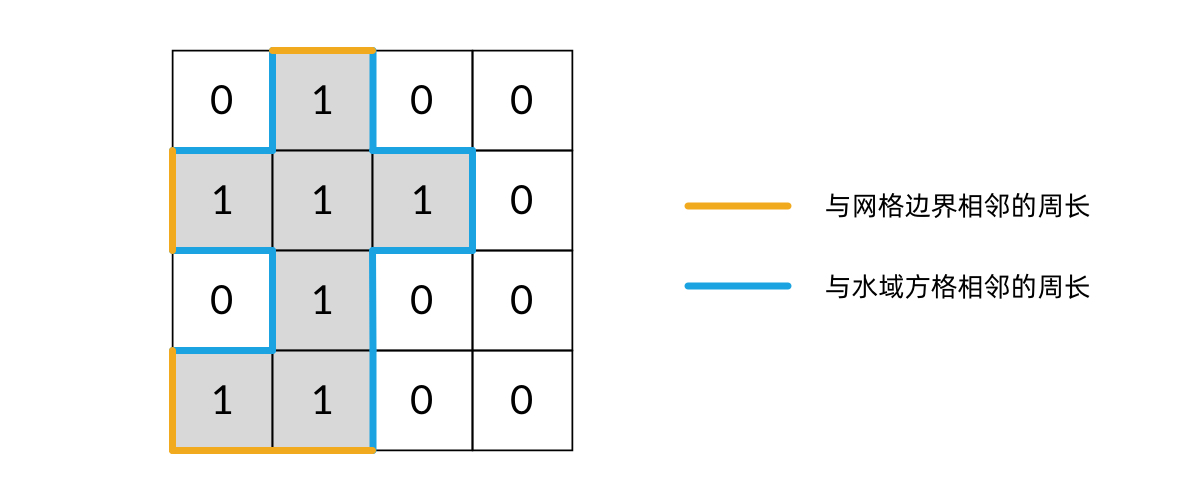

In [21]:
grid = [[0,1,0,0],[1,1,1,0],[0,1,0,0],[1,1,0,0]]
def islandPerimeter(grid):
    """
    :type grid: List[List[int]]
    :rtype: int
    """
    global_visited = [[grid[ii][jj] for jj in range(len(grid[0]))] for ii in range(len(grid))]
    for mm in range(len(grid)):
        for nn in range(len(grid[0])):
            if global_visited[mm][nn] == 1:
                record = set([(mm, nn)])
                global_visited[mm][nn] = 0
                count = 0
                while record:
                    record_new = set()
                    for ii, jj in record:
                        if 0 <= ii - 1:
                            if global_visited[ii - 1][jj] == 1:
                                record_new.add((ii - 1, jj))
                                global_visited[ii - 1][jj] = 0
                            if grid[ii - 1][jj] == 0:
                                count += 1
                        else:
                            count += 1
                        if ii + 1 < len(grid):
                            if global_visited[ii + 1][jj] == 1:
                                record_new.add((ii + 1, jj))
                                global_visited[ii + 1][jj] = 0
                            if grid[ii + 1][jj] == 0:
                                count += 1
                        else:
                            count += 1
                        if 0 <= jj - 1:
                            if global_visited[ii][jj - 1] == 1:
                                record_new.add((ii, jj - 1))
                                global_visited[ii][jj - 1] = 0
                            if grid[ii][jj - 1] == 0:
                                count += 1
                        else:
                            count += 1
                        if jj + 1 < len(grid[0]):
                            if global_visited[ii][jj + 1] == 1:
                                record_new.add((ii, jj + 1))
                                global_visited[ii][jj + 1] = 0
                            if grid[ii][jj + 1] == 0:
                                count += 1
                        else:
                            count += 1
                    record = record_new
                return count

islandPerimeter(grid)

16

<span id='P.1162'></span>
### [1162. 地图分析](https://leetcode.cn/problems/as-far-from-land-as-possible/)

你现在手里有一份大小为`n x n`的 网格`grid`，上面的每个 单元格 都用`0`和`1`标记好了。其中`0`代表海洋，`1`代表陆地。

请你找出一个海洋单元格，这个海洋单元格到离它最近的陆地单元格的距离是最大的，并返回该距离。如果网格上只有陆地或者海洋，请返回`-1`。

我们这里说的距离是「曼哈顿距离」(Manhattan Distance): `(x0, y0)`和`(x1, y1)`这两个单元格之间的距离是`|x0 - x1| + |y0 - y1|`。

**题解**: 先把所有的陆地都入队，然后从各个陆地同时开始一层一层的向海洋扩散，那么最后扩散到的海洋就是最远的海洋
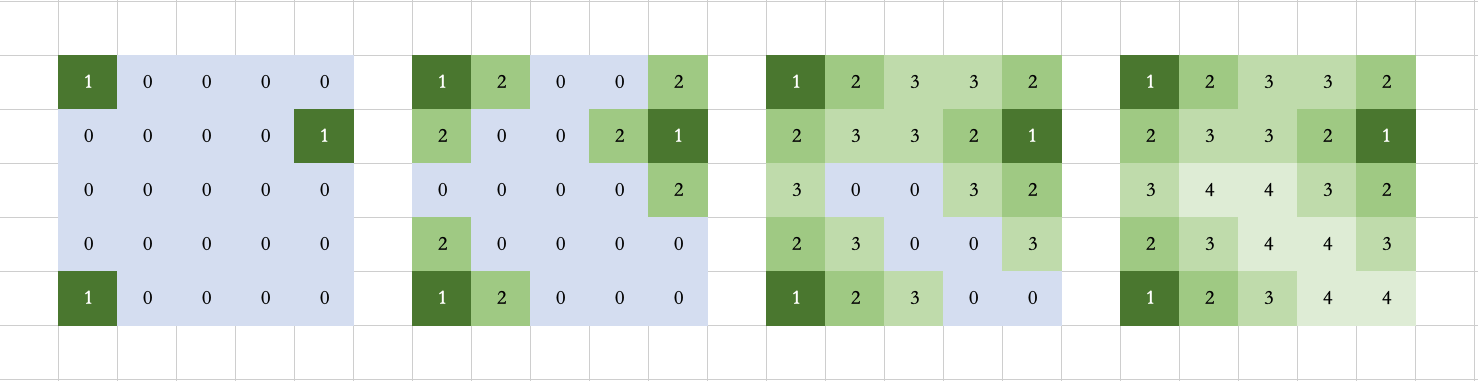

In [20]:
grid = [[1, 0, 0, 0, 0], [0, 0, 0, 0, 1], [0, 0, 0, 0, 0], [0, 0, 0, 0, 0], [1, 0, 0, 0, 0]]

set_sea = set()
set_land = set()
for i in range(len(grid)):
    for j in range(len(grid[0])):
        if grid[i][j] == 1:
            set_land.add((i, j))
        else:
            set_sea.add((i, j))

if len(set_sea) == 0 or len(set_land) == 0:
    print( - 1 )
else:
    dist = 0
    while set_land:
        temp = set()
        for i, j in set_land:
            coordinates = (i + 1, j) 
            if coordinates in set_sea:
                set_sea.remove(coordinates)
                temp.add(coordinates)
            coordinates = (i, j + 1) 
            if coordinates in set_sea:
                set_sea.remove(coordinates)
                temp.add(coordinates)
            coordinates = (i - 1, j) 
            if coordinates in set_sea:
                set_sea.remove(coordinates)
                temp.add(coordinates)
            coordinates = (i, j - 1) 
            if coordinates in set_sea:
                set_sea.remove(coordinates)
                temp.add(coordinates)
    
        set_land = temp
        dist += 1
        print("set_land =", set_land, ", dist =", dist)
    print( dist - 1 )

set_land = {(0, 1), (2, 4), (0, 4), (4, 1), (3, 0), (1, 0), (1, 3)} , dist = 1
set_land = {(1, 2), (3, 4), (3, 1), (1, 1), (0, 3), (2, 0), (4, 2), (2, 3), (0, 2)} , dist = 2
set_land = {(4, 4), (2, 1), (4, 3), (3, 3), (2, 2), (3, 2)} , dist = 3
set_land = set() , dist = 4
3


<span id='P.994'></span> 
#### [994. 腐烂的橘子](https://leetcode.cn/problems/rotting-oranges)
在给定的`m x n`网格`grid`中，每个单元格可以有以下三个值之一：
- 值`0`代表空单元格；
- 值`1`代表新鲜橘子；
- 值`2`代表腐烂的橘子。

每分钟，腐烂的橘子**周围 4 个方向上相邻**的新鲜橘子都会腐烂。<br>
返回*直到单元格中没有新鲜橘子为止所必须经过的最小分钟数。如果不可能，返回*`-1`。

**示例 1**：
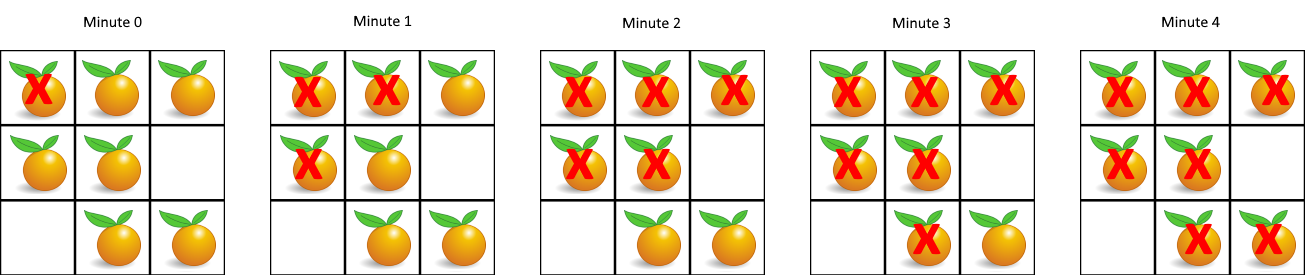
> 输入：grid = [[2,1,1],[1,1,0],[0,1,1]]<br>
> 输出：4

In [ ]:
grid = [[2,1,1],[1,1,0],[0,1,1]]

set2 = set()
set1 = set()
for ii in range(len(grid)):
    for jj in range(len(grid[0])):
        if grid[ii][jj] == 2:
            set2.add((ii, jj))
        elif grid[ii][jj] == 1:
            set1.add((ii, jj))
time = 0
if len(set1) == 0:
    return 0
while set2:
    temp = set()
    for ii, jj in set2:
        if 0 <= ii - 1 and (ii - 1, jj) in set1:
            temp.add((ii - 1, jj))
            set1.remove((ii - 1, jj))
        if ii + 1 < len(grid) and (ii + 1, jj) in set1:
            temp.add((ii + 1, jj))
            set1.remove((ii + 1, jj))
        if 0 <= jj - 1 and (ii, jj - 1) in set1:
            temp.add((ii, jj - 1))
            set1.remove((ii, jj - 1))
        if jj + 1 < len(grid[0]) and (ii, jj + 1) in set1:
            temp.add((ii, jj + 1))
            set1.remove((ii, jj + 1))
    set2 = temp
    time += 1
    # print("------")
    # print("set2 =", set2)
    # print("set1 =", set1)
    # print("time =", time)
if len(set1) > 0:
    return -1
else:
    return time - 1

In [ ]:
#include <iostream>
#include <vector>

int orangesRotting(std::vector<std::vector<int>>& grid) {
    std::vector<std::vector<int>> record;
    for (int ii = 0; ii < grid.size(); ii++) {
        for (int jj = 0; jj < grid[0].size(); jj++) {
            if (grid[ii][jj] == 2) {
                std::vector<int> coordinate = {ii, jj};
                record.emplace_back(coordinate);
            }
        }
    }
    int count = 0;
    std::vector<int> coor_next;
    while (record.size() > 0) {
        std::vector<std::vector<int>> record_new;
        for (auto coor : record) {
            int ii = coor[0];
            int jj = coor[1];
            if (ii - 1 >= 0 && grid[ii - 1][jj] == 1) {
                coor_next = {ii - 1, jj};
                grid[ii - 1][jj] = 2;
                record_new.emplace_back(coor_next);
            }
            if (ii + 1 < grid.size() && grid[ii + 1][jj] == 1) {
                coor_next = {ii + 1, jj};
                grid[ii + 1][jj] = 2;
                record_new.emplace_back(coor_next);
            }
            if (jj - 1 >= 0 && grid[ii][jj - 1] == 1) {
                coor_next = {ii, jj - 1};
                grid[ii][jj - 1] = 2;
                record_new.emplace_back(coor_next);
            }
            if (jj + 1 < grid[0].size() && grid[ii][jj + 1] == 1) {
                coor_next = {ii, jj + 1};
                grid[ii][jj + 1] = 2;
                record_new.emplace_back(coor_next);
            }
        }
        if (record_new.size() > 0) {
            count += 1;
        }
        record.swap(record_new);
    }
    for (int ii = 0; ii < grid.size(); ii++) {
        for (int jj = 0; jj < grid[0].size(); jj++) {
            if (grid[ii][jj] == 1) {
                return -1;
            }
        }
    }
    return count;
}

In [ ]:
std::vector<int> row1 = {2,1,1};
std::vector<int> row2 = {1,1,0};
std::vector<int> row3 = {0,1,1};
std::vector<std::vector<int>> grid;
grid.emplace_back(row1);
grid.emplace_back(row2);
grid.emplace_back(row3);
std::cout << orangesRotting(grid) << std::endl;

# todo
https://zhuanlan.zhihu.com/p/656641191